## Priors
There are several parameters in the models that have priors. Both models use the same priors for the parameters that they have in common, and the second model has additional parameters with their own priors. The priors are as follows:
- `alpha`: expected value of $log(PR)$
- `beta`: expected change in $log(PR)$ per $\Delta T=1^{\circ}C$
- `sigma`: standard deviation of the Student-t distribution of $log(PR)$
- `nu`: degrees of freedom for the Student-t distribution of $log(PR)$

Only in the second model:
- `sigma_day`: scale parameter for day-level variation in Model 2. It controls how strongly individual days can deviate from the global temperature trend on the `log(PR)` scale. Larger values indicate stronger day-to-day variability not explained by temperature alone.
- `z_day_raw`: standardized latent daily effects. Each day receives a raw effect drawn from `Normal(0, 1)`. These raw effects are centered and multiplied by `sigma_day` to obtain the actual daily offsets:

  $$\delta_d = \sigma_{day}(z_{day,d} - \bar{z}_{day})$$


### Model 1: Prior predictive checks
The first model has the following priors:
- `alpha` ~ Normal(log(0.8), 0.3)

Justification: the average value of \(PR\) is usually around 88-93% [2]. We decided to use a slightly weaker prior mean of 75% to allow for some bias in the data and to give the model more room to learn from the data. The standard deviation of 0.3 allows for a wide range of plausible average performance values.

- `beta_T_10C` ~ Normal(-0.035, 0.05)

The prior mean of -0.035 corresponds to a 3.5% decrease in \(PR\) per 10°C increase in temperature, which is a reasonable starting point based on previous studies [3]. The standard deviation of 0.05 allows for a wide range of plausible effects, including no effect and stronger effects.

- `sigma` ~ Exponential(10)

This prior places more weight on smaller values but stills allows a wide range of values.

- `nu` ~ 5 + Exponential(0.1)

This prior allows for a wide range of degrees of freedom, starting from 5 (which corresponds to a moderately heavy-tailed distribution) and allowing for much heavier tails as well.

In [29]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
import pickle
import arviz as az

RANDOM_SEED = 42
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

In [30]:
DATA_PATH = "Bayesian-Data-Analytics-PV-Project/onemin-Ground-2016/2016/ground_model_data_9_16_5min.csv"
STAN_PRIOR_PATH = Path("Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt_prior_predictive.stan")

df = pd.read_csv(DATA_PATH)

required = ["logPR", "PR", "T_module_C"]

df = df[df["hour"] >= 9]
df = df[df["hour"] <= 16]

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=required).copy()

temp_min = df["T_module_C"].min()
temp_max = df["T_module_C"].max()
temp_range = temp_max - temp_min
df["x_T"] = (df["T_module_C"] - temp_min) / temp_range

if "day_id" in df.columns:
    df["day_id"] = pd.factorize(df["day_id"])[0] + 1

y = df["logPR"].to_numpy()
x_T = df["x_T"].to_numpy()
N = len(df)
print(N)

T_range_C = float(df["T_module_C"].max() - df["T_module_C"].min())

4026


In [31]:
with open(STAN_PRIOR_PATH) as f:
    print(f.read())

data {
  int<lower=1> N;
  vector[N] x_T;              // normalized module temperature in [0, 1]
  real<lower=0> T_range_C;    // T_max - T_min in degC
}

generated quantities {
  real alpha;
  real beta_T_10C;
  real beta_T_norm;

  real sigma;
  real nu_min5;
  real nu;

  real effect_10C_pct;
  real effect_1C_pct;
  real effect_full_range_pct;

  vector[N] mu;
  vector[N] y_prior;
  vector[N] PR_prior;

  alpha = normal_rng(log(0.8), 0.3);

  beta_T_10C = normal_rng(-0.035, 0.05);

  // Convert to coefficient for x_T in [0, 1]
  beta_T_norm = beta_T_10C * T_range_C / 10.0;

  sigma = exponential_rng(10);
  while (sigma <= 0.001 || sigma >= 1) {
    sigma = exponential_rng(10);
  }

  nu_min5 = exponential_rng(0.1);
  while (nu_min5 <= 0 || nu_min5 >= 45) {
    nu_min5 = exponential_rng(0.1);
  }
  nu = 5 + nu_min5;

  for (i in 1:N) {
    mu[i] = alpha + beta_T_norm * x_T[i];

    y_prior[i] = student_t_rng(nu, mu[i], sigma);
    PR_prior[i] = exp(y_prior[i]);
  }
}



01:28:10 - cmdstanpy - INFO - compiling stan file /workspace/Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt_prior_predictive.stan to exe file /workspace/Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt_prior_predictive
01:28:33 - cmdstanpy - INFO - compiled model executable: /workspace/Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt_prior_predictive
01:28:33 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

01:28:46 - cmdstanpy - INFO - CmdStan done processing.


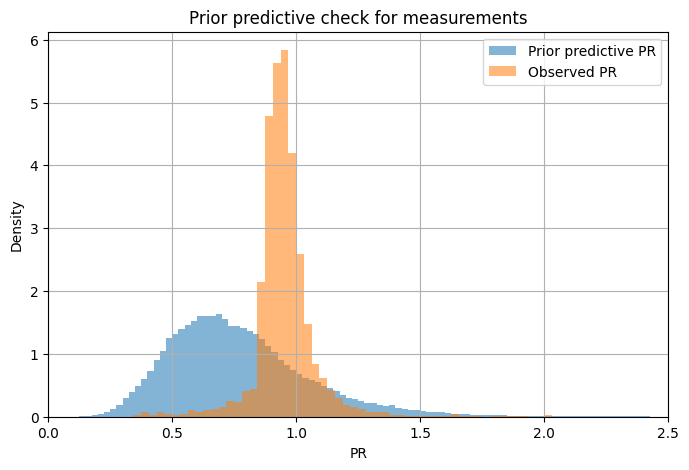

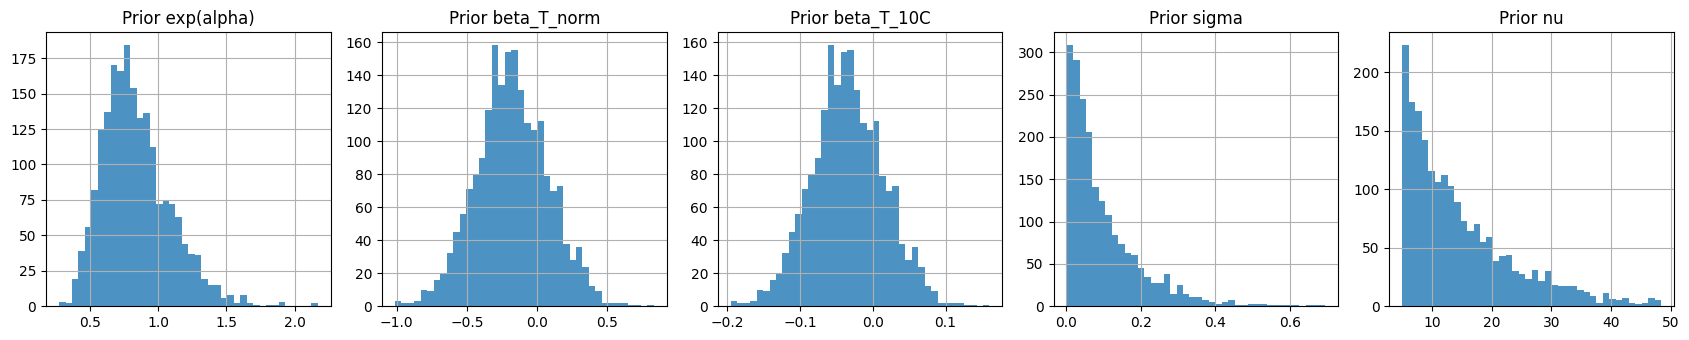

In [32]:
stan_data = {
    "N": N,
    "y": y,
    "x_T": x_T,
    "T_range_C": T_range_C,
}

prior_data = {
    "N": N,
    "x_T": x_T,
    "T_range_C": T_range_C,
}

prior_model = CmdStanModel(stan_file=str(STAN_PRIOR_PATH), force_compile=True)

prior_fit = prior_model.sample(
    data=prior_data,
    fixed_param=True,
    chains=1,
    iter_sampling=2000,
    seed=RANDOM_SEED,
)

alpha_prior = prior_fit.stan_variable("alpha")
beta_T_10C_prior = prior_fit.stan_variable("beta_T_10C")
beta_T_norm_prior = prior_fit.stan_variable("beta_T_norm")
sigma_prior = prior_fit.stan_variable("sigma")
nu_prior = prior_fit.stan_variable("nu")
PR_prior = prior_fit.stan_variable("PR_prior")

plt.figure()
plt.hist(PR_prior.flatten(), bins=100, range=(0, 2.5), density=True, alpha=0.55, label="Prior predictive PR")
plt.hist(df["PR"], bins=80,range=(0, 2.5), density=True, alpha=0.55, label="Observed PR")
plt.xlim(0, 2.5)
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Prior predictive check for measurements")
plt.xlim([0, 2.5])
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(17, 3.5))
for ax, (name, samples) in zip(
    axes,
    [
        ("exp(alpha)", np.exp(alpha_prior)),
        ("beta_T_norm", beta_T_norm_prior),
        ("beta_T_10C", beta_T_10C_prior),
        ("sigma", sigma_prior),
        ("nu", nu_prior),
    ]
):
    ax.hist(samples, bins=40, alpha=0.8)
    ax.set_title(f"Prior {name}")
    ax.grid(True)
plt.tight_layout()
plt.show()

The prior predictive distribution is deliberately wider than the observed data. This means that the priors do not strongly constrain the model. In other words, the priors are weakly informative: they allow a broad range of possible outcomes.

As a result, the prior predictive check does not match the observed distribution closely, which is expected. A close match between the prior predictive distribution and the observed data could indicate that the priors are too specialized or too strongly informed by the data.

### Model 2: Prior predictive checks
The second model has the same priors for `alpha`, `beta_T_10C`, `sigma`, and `nu` as the first model, and it has additional priors for the day-level parameters:
- `sigma_day` ~ Normal(0, 1), half-normal on the positive side

This prior allows for a wide range of day-level variability, with most of the mass near zero but allowing for larger values as well.

- `z_day_raw` ~ Normal(0, 1)

This prior assumes that the raw day effects are centered around zero, allowing for both positive and negative deviations from the global trend.

In [33]:
STAN_PRIOR_PATH = "Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset_prior_predictive.stan"
with open(STAN_PRIOR_PATH) as f:
    print(f.read())

data {
  int<lower=1> N;
  int<lower=1> J;
  vector[N] x_T;
  real<lower=0> temp_range;
  array[N] int<lower=1, upper=J> day_id;
}

generated quantities {
  real alpha;
  real beta_T;
  real sigma;
  real sigma_day;
  real nu_min5;
  real nu;
  real beta_T_per_10C;

  vector[J] z_day_raw;
  vector[J] delta_day;

  vector[N] mu;
  vector[N] y_prior;
  vector[N] PR_prior;

  alpha = normal_rng(log(0.8), 0.3);
  beta_T_per_10C = normal_rng(-0.035, 0.05);
  beta_T = beta_T_per_10C * temp_range / 10;

  sigma = exponential_rng(10);
  while (sigma <= 0.001 || sigma >= 1) {
    sigma = exponential_rng(10);
  }

  nu_min5 = exponential_rng(0.1);
  while (nu_min5 <= 0 || nu_min5 >= 45) {
    nu_min5 = exponential_rng(0.1);
  }
  nu = 5 + nu_min5;

  sigma_day = normal_rng(0, 1);
  while (sigma_day <= 0) {
    sigma_day = normal_rng(0, 1);
  }

  for (j in 1:J) {
    z_day_raw[j] = normal_rng(0, 1);
  }

  delta_day = sigma_day * (z_day_raw - mean(z_day_raw));

  for (i in 1:N) {
    mu[i] = alp

4026


01:28:57 - cmdstanpy - INFO - compiling stan file /workspace/Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset_prior_predictive.stan to exe file /workspace/Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset_prior_predictive
01:29:19 - cmdstanpy - INFO - compiled model executable: /workspace/Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset_prior_predictive
01:29:19 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

01:29:26 - cmdstanpy - INFO - CmdStan done processing.


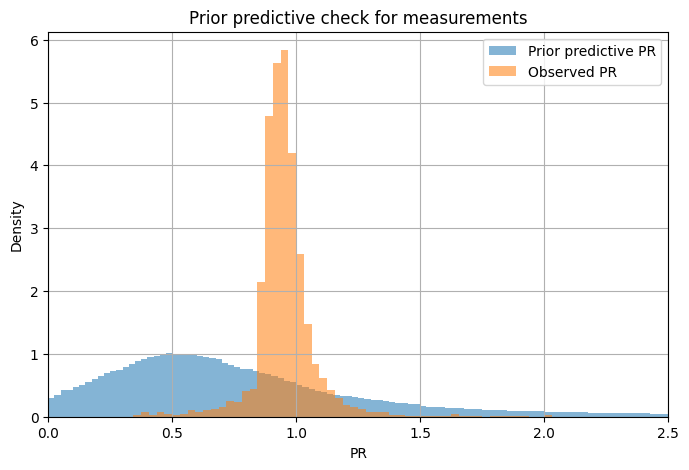

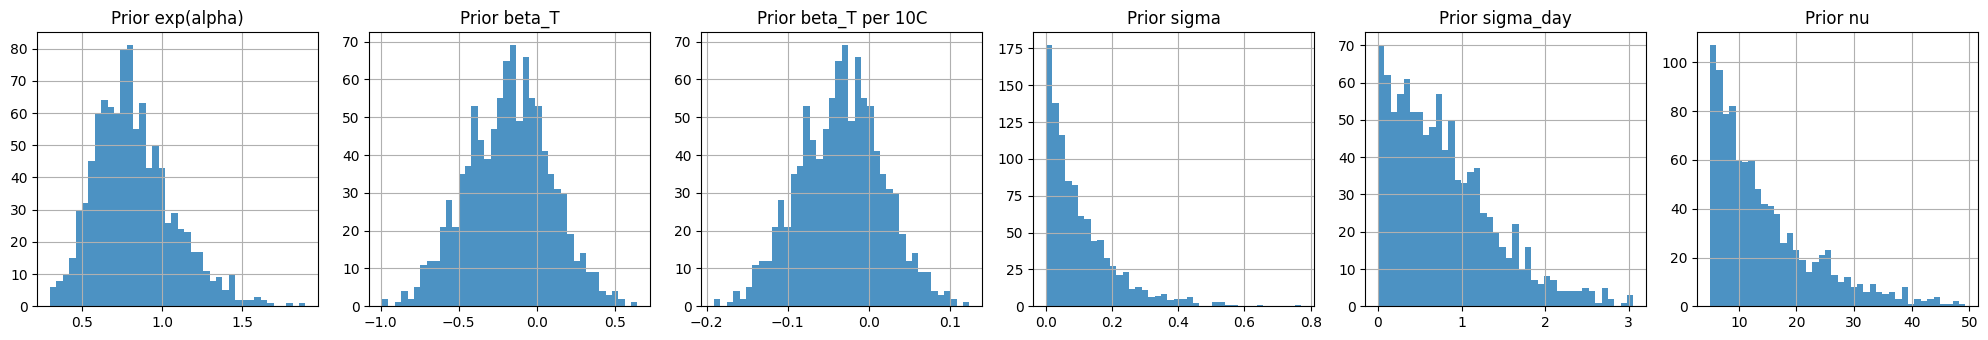

In [34]:
y = df["logPR"].to_numpy()
x_T = df["x_T"].to_numpy()
day_id = df["day_id"].astype(int).to_numpy()

N = len(df)
print(N)
J = int(df["day_id"].max())

prior_data = {
    "N": N,
    "J": J,
    "x_T": x_T,
    "temp_range": temp_range,
    "day_id": day_id,
}

prior_model = CmdStanModel(stan_file=str(STAN_PRIOR_PATH), force_compile=True)

prior_fit = prior_model.sample(
    data=prior_data,
    fixed_param=True,
    chains=1,
    iter_sampling=1000,
    seed=RANDOM_SEED,
)

alpha_prior = prior_fit.stan_variable("alpha")
beta_T_prior = prior_fit.stan_variable("beta_T")
beta_T_per_10C_prior = prior_fit.stan_variable("beta_T_per_10C")
sigma_prior = prior_fit.stan_variable("sigma")
sigma_day_prior = prior_fit.stan_variable("sigma_day")
nu_prior = prior_fit.stan_variable("nu")
PR_prior = prior_fit.stan_variable("PR_prior")

plt.figure(figsize=(8, 5))
plt.hist(PR_prior.flatten(), range=(0, 2.5), bins=100, density=True, alpha=0.55, label="Prior predictive PR")
plt.hist(df["PR"], bins=80, range=(0, 2.5), density=True, alpha=0.55, label="Observed PR")
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Prior predictive check for measurements")
plt.xlim([0, 2.5])
plt.legend()
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 6, figsize=(20, 3.5))
prior_samples = [
    ("exp(alpha)", np.exp(alpha_prior)),
    ("beta_T", beta_T_prior),
    ("beta_T per 10C", beta_T_per_10C_prior),
    ("sigma", sigma_prior),
    ("sigma_day", sigma_day_prior),
    ("nu", nu_prior),
]

for ax, (name, samples) in zip(axes, prior_samples):
    ax.hist(samples, bins=40, alpha=0.8)
    ax.set_title(f"Prior {name}")
    ax.grid(True)

plt.tight_layout()
plt.show()


Prior predictive checks for Model 2 show that the prior predictive distribution is wider than the observed data, similar to Model 1. This indicates that the priors are weakly informative and allow for a broad range of possible outcomes. The additional day-level parameters introduce more variability, which is reflected in the prior predictive distribution.

## Model 1 - Posterior Analysis


In [35]:
STAN_MODEL_1_PATH = Path("Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt.stan")
with open(STAN_MODEL_1_PATH) as f:    print(f.read())

data {
  int<lower=1> N;
  vector[N] y;                // log(PR)
  vector[N] x_T;              // normalized module temperature in [0, 1]
  real<lower=0> T_range_C;    // T_max - T_min in degC
}

parameters {
  real alpha;

  // Interpretable coefficient:
  // effect on log(PR) for +10 degC module temperature increase
  real beta_T_10C;

  real<lower=0.001, upper=1> sigma;
  real<lower=0, upper=45> nu_min5;
}

transformed parameters {
  real beta_T_norm;
  real<lower=5, upper=50> nu;
  vector[N] mu;

  // Convert +10 degC coefficient to coefficient for x_T in [0, 1]
  // If x_T changes from 0 to 1, temperature changes by T_range_C.
  beta_T_norm = beta_T_10C * T_range_C / 10.0;
  nu = 5 + nu_min5; // liczba stopni swobody dla rozkładu t-Studenta - mniejsza wartość oznacza grubsze ogony, większą odporność na obserwacje odstające

  mu = alpha + beta_T_norm * x_T;
}

model {
  // Baseline log(PR) at the lowest module temperature in the dataset.
  // Broad weakly informative prior.
  alp

In [36]:
stan_data = {
    "N": N,
    "y": y,
    "x_T": x_T,
    "T_range_C": T_range_C,
}

model = CmdStanModel(stan_file=str(STAN_MODEL_1_PATH), force_compile=True)
fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=RANDOM_SEED,
    adapt_delta=0.95,
    max_treedepth=12,
)

01:29:31 - cmdstanpy - INFO - compiling stan file /workspace/Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt.stan to exe file /workspace/Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt
01:30:03 - cmdstanpy - INFO - compiled model executable: /workspace/Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt
01:30:03 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

01:30:41 - cmdstanpy - INFO - CmdStan done processing.


### Diagnostics

In [37]:
print(fit.diagnose())
summary = fit.summary()
display(summary.loc[["alpha", "beta_T_10C", "beta_T_norm", "sigma", "nu"]])

draws_pd = fit.draws_pd()
div_cols = [c for c in draws_pd.columns if c.endswith("__") and "divergent" in c]
n_div = int(draws_pd[div_cols[0]].sum()) if div_cols else 0
print("Number of divergences:", n_div)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
alpha,0.126721,0.000070,0.003632,0.003709,0.120745,0.126746,0.132536,2673.28,2355.90,1.00200
beta_T_10C,-0.057496,0.000021,0.001110,0.001156,-0.059286,-0.057513,-0.055707,2759.49,2379.85,1.00155
beta_T_norm,-0.298403,0.000110,0.005758,0.005999,-0.307693,-0.298492,-0.289119,2759.48,2379.85,1.00155
sigma,0.054823,0.000018,0.000861,0.000838,0.053436,0.054789,0.056300,2220.63,2133.41,1.00195
nu,5.007600,0.000153,0.007662,0.005382,5.000440,5.005240,5.022600,1643.21,1028.46,1.00336


Number of divergences: 0


#### Sampling diagnostics summary
The sampler diagnostics did not indicate sampling problems for Model 1: no divergent transitions were found, E-BFMI was satisfactory, and the reported R-hat values were close to 1. Because the diagnostics were satisfactory, no additional mitigation was needed.

[5.0004395 5.00524   5.022605 ]


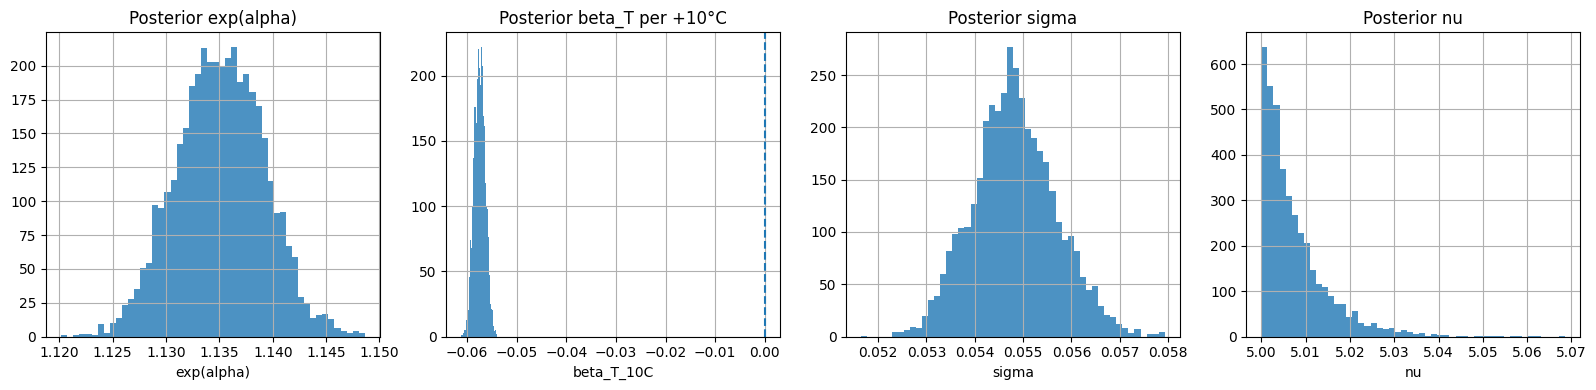

In [38]:
alpha = fit.stan_variable("alpha")
beta_T_10C = fit.stan_variable("beta_T_10C")
beta_T_norm = fit.stan_variable("beta_T_norm")
sigma = fit.stan_variable("sigma")
nu = fit.stan_variable("nu")
mu = fit.stan_variable("mu")

print(np.percentile(nu, [5, 50, 95]))
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plots = [
    ("Posterior exp(alpha)", np.exp(alpha), "exp(alpha)", False),
    ("Posterior beta_T per +10°C", beta_T_10C, "beta_T_10C", True),
    ("Posterior sigma", sigma, "sigma", False),
    ("Posterior nu", nu, "nu", False),
]
for ax, (title, samples, xlabel, zero) in zip(axes, plots):
    ax.hist(samples, bins=50, alpha=0.8)
    if zero:
        ax.axvline(0, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True)
plt.tight_layout()
plt.show()

#### Marginal posterior distributions
The posterior $exp(alpha)$ represents the expected PR at the lowest observed temperature. Its values are concentrated above 1, which is expected because the estimated temperature effect is negative, so PR decreases as temperature increases. The posterior for beta_T_10C is concentrated below zero, indicating a stable negative temperature effect, while sigma and nu summarize the residual spread and tail heaviness of the Student-t likelihood.

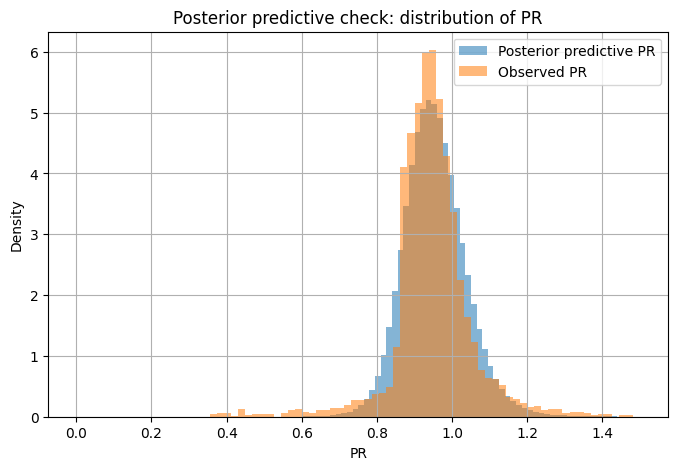

In [39]:
PR_pred = fit.stan_variable("PR_pred")
y_pred = fit.stan_variable("y_pred")

plt.figure(figsize=(8, 5))

plt.hist(
    PR_pred.flatten(),
    bins=100,
    range=(0, 1.5),
    density=True,
    alpha=0.55,
    label="Posterior predictive PR"
)

plt.hist(
    df["PR"],
    bins=80,
    range=(0, 1.5),
    density=True,
    alpha=0.55,
    label="Observed PR"
)

plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Posterior predictive check: distribution of PR")
plt.legend()
plt.grid(True)
plt.show()

The posterior predictive distribution of PR is more concentrated around the observed data compared to the prior predictive distribution, which indicates that the model has learned from the data. The posterior predictive samples are analyzed by comparing their distribution with the empirical PR distribution.

The observed data are broadly consistent with the posterior predictive samples: the main mass of the observed PR distribution is covered by the posterior predictive distribution. Remaining differences are expected because Model 1 is simple and only includes temperature.

### Residual diagnostics: motivation for Model 2

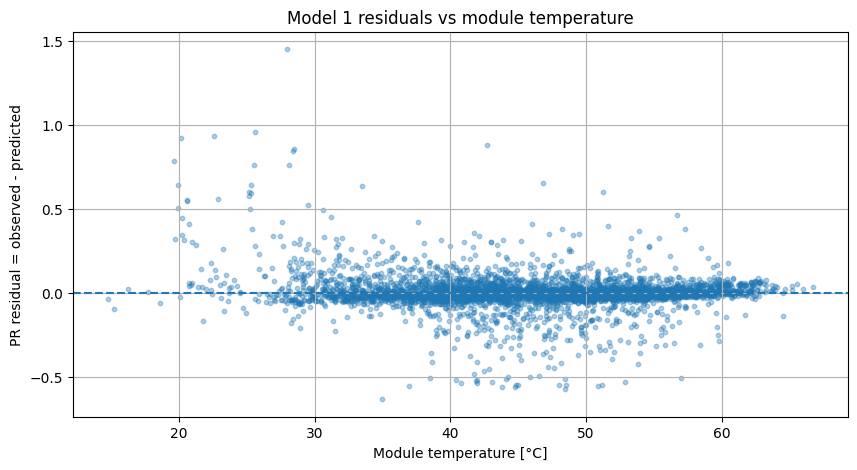

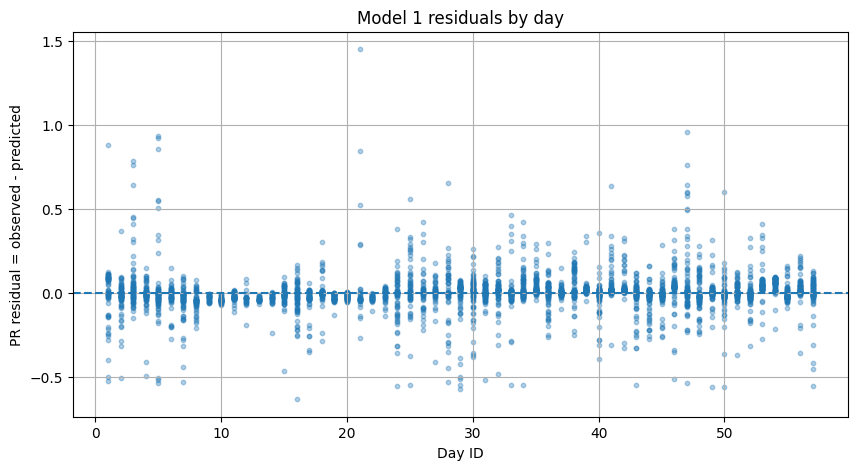

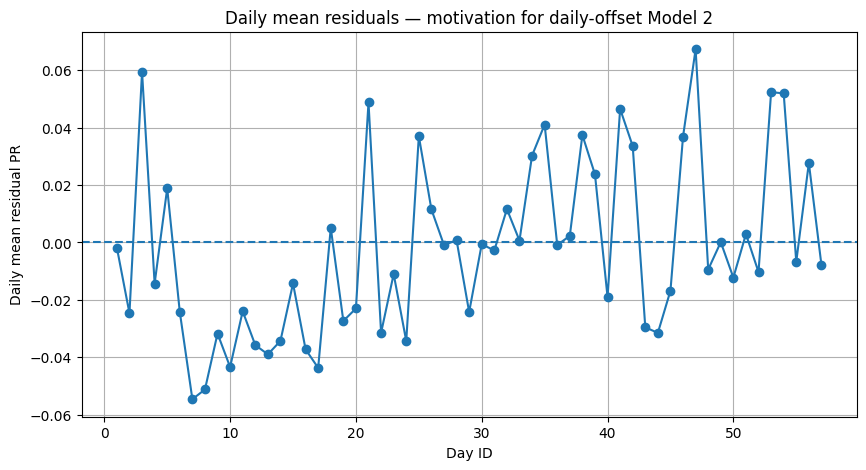

In [40]:
PR_mu_mean = np.exp(mu).mean(axis=0)

df_check = df.copy()
df_check["PR_pred_mean"] = PR_mu_mean
df_check["residual_PR"] = df_check["PR"] - df_check["PR_pred_mean"]

plt.figure(figsize=(10, 5))
plt.scatter(df_check["T_module_C"], df_check["residual_PR"], s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Module temperature [°C]")
plt.ylabel("PR residual = observed - predicted")
plt.title("Model 1 residuals vs module temperature")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(df_check["day_id"], df_check["residual_PR"], s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Day ID")
plt.ylabel("PR residual = observed - predicted")
plt.title("Model 1 residuals by day")
plt.show()

daily_res = df_check.groupby("day_id").agg(daily_mean_residual=("residual_PR", "mean")).reset_index()
plt.figure(figsize=(10, 5))
plt.plot(daily_res["day_id"], daily_res["daily_mean_residual"], "o-")
plt.axhline(0, linestyle="--")
plt.xlabel("Day ID")
plt.ylabel("Daily mean residual PR")
plt.title("Daily mean residuals — motivation for daily-offset Model 2")
plt.show()

In [41]:
idata1 = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive=["y_pred"],
    observed_data={"y": y},
    log_likelihood=["log_lik"],
)


with open("idata_model1_temperature_studentt.pkl", "wb") as f:
    pickle.dump(idata1, f)

## Model 2 - Posterior Analysis

In [42]:
STAN_MODEL_2_PATH = "Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset.stan"

print("Using Stan model:", STAN_MODEL_2_PATH)

with open(STAN_MODEL_2_PATH, "r", encoding="utf-8") as f:
    print(f.read())

Using Stan model: Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset.stan
data {
  int<lower=1> N;
  int<lower=1> J;
  vector[N] y;
  vector[N] x_T;
  real<lower=0> temp_range;
  array[N] int<lower=1, upper=J> day_id;
}

parameters {
  real alpha;
  real beta_T_per_10C;
  real<lower=0.001, upper=1> sigma;
  real<lower=0> sigma_day;
  real<lower=0, upper=45> nu_min5;
  vector[J] z_day_raw;
}

transformed parameters {
  real beta_T;
  real<lower=5, upper=50> nu;
  vector[J] delta_day;
  vector[N] mu;

  beta_T = beta_T_per_10C * temp_range / 10;
  nu = 5 + nu_min5;
  delta_day = sigma_day * (z_day_raw - mean(z_day_raw));

  for (i in 1:N) {
    mu[i] = alpha + beta_T * x_T[i] + delta_day[day_id[i]];
  }
}

model {
  alpha ~ normal(log(0.8), 0.3);
  beta_T_per_10C ~ normal(-0.035, 0.05);
  sigma ~ exponential(10);
  nu_min5 ~ exponential(0.1);
  sigma_day ~ normal(0, 1);
  z_day_raw ~ normal(0, 1);

  y ~ student_t(nu, mu, sigma);
}

generated quantities {
  vector[N] y_p

In [43]:
stan_data = {
    "N": N,
    "J": J,
    "y": y,
    "x_T": x_T,
    "temp_range": T_range_C,
    "day_id": day_id,
}

model = CmdStanModel(stan_file=str(STAN_MODEL_2_PATH), force_compile=True)
fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=RANDOM_SEED,
    adapt_delta=0.95,
    max_treedepth=12,
)

fit

01:34:58 - cmdstanpy - INFO - compiling stan file /workspace/Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset.stan to exe file /workspace/Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset
01:35:34 - cmdstanpy - INFO - compiled model executable: /workspace/Bayesian-Data-Analytics-PV-Project/model_2_temperature_daily_offset
01:35:34 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

01:39:06 - cmdstanpy - INFO - CmdStan done processing.


CmdStanMCMC: model=model_2_temperature_daily_offset chains=4['method=sample', 'num_samples=1000', 'num_warmup=1000', 'algorithm=hmc', 'engine=nuts', 'max_depth=12', 'adapt', 'engaged=1', 'delta=0.95']
 csv_files:
	/tmp/tmplu14kbgn/model_2_temperature_daily_offset648czj4_/model_2_temperature_daily_offset-20260621013534_1.csv
	/tmp/tmplu14kbgn/model_2_temperature_daily_offset648czj4_/model_2_temperature_daily_offset-20260621013534_2.csv
	/tmp/tmplu14kbgn/model_2_temperature_daily_offset648czj4_/model_2_temperature_daily_offset-20260621013534_3.csv
	/tmp/tmplu14kbgn/model_2_temperature_daily_offset648czj4_/model_2_temperature_daily_offset-20260621013534_4.csv
 output_files:
	/tmp/tmplu14kbgn/model_2_temperature_daily_offset648czj4_/model_2_temperature_daily_offset-20260621013534_0-stdout.txt
	/tmp/tmplu14kbgn/model_2_temperature_daily_offset648czj4_/model_2_temperature_daily_offset-20260621013534_1-stdout.txt
	/tmp/tmplu14kbgn/model_2_temperature_daily_offset648czj4_/model_2_temperature_d

### Diagnostics

In [44]:
print(fit.diagnose())
summary = fit.summary()
display(summary.loc[["alpha", "beta_T_per_10C", "beta_T", "sigma", "sigma_day", "nu"]])

draws_pd = fit.draws_pd()
div_cols = [c for c in draws_pd.columns if c.endswith("__") and "divergent" in c]
n_div = int(draws_pd[div_cols[0]].sum()) if div_cols else 0
print("Number of divergences:", n_div)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
alpha,0.182110,0.000088,0.004476,0.004332,0.174695,0.182052,0.189595,2642.780,2902.100,1.00308
beta_T_per_10C,-0.075874,0.000028,0.001407,0.001359,-0.078202,-0.075865,-0.073523,2571.930,2896.450,1.00318
beta_T,-0.393789,0.000144,0.007302,0.007053,-0.405868,-0.393740,-0.381583,2571.920,2896.450,1.00318
sigma,0.046066,0.000013,0.000801,0.000839,0.044785,0.046058,0.047384,3974.650,2857.490,0.99951
sigma_day,0.032627,0.000173,0.003428,0.003292,0.027561,0.032253,0.038816,388.752,938.008,1.00863
nu,5.005780,0.000077,0.005995,0.004092,5.000300,5.003890,5.017510,3347.040,1940.800,1.00163


Number of divergences: 0


### Sampling diagnostics summary

The sampler diagnostics did not indicate serious sampling problems for Model 2: no divergent transitions were found, E-BFMI was satisfactory, and the reported R-hat values were close to 1. This suggests that the posterior distribution of the temperature coefficient, residual noise, daily-offset scale and day-level effects was explored reliably. 

nu [5%, 50%, 95%]: [5.0003   5.00389  5.017512]
sigma_day [5%, 50%, 95%]: [0.02756068 0.0322535  0.03881598]


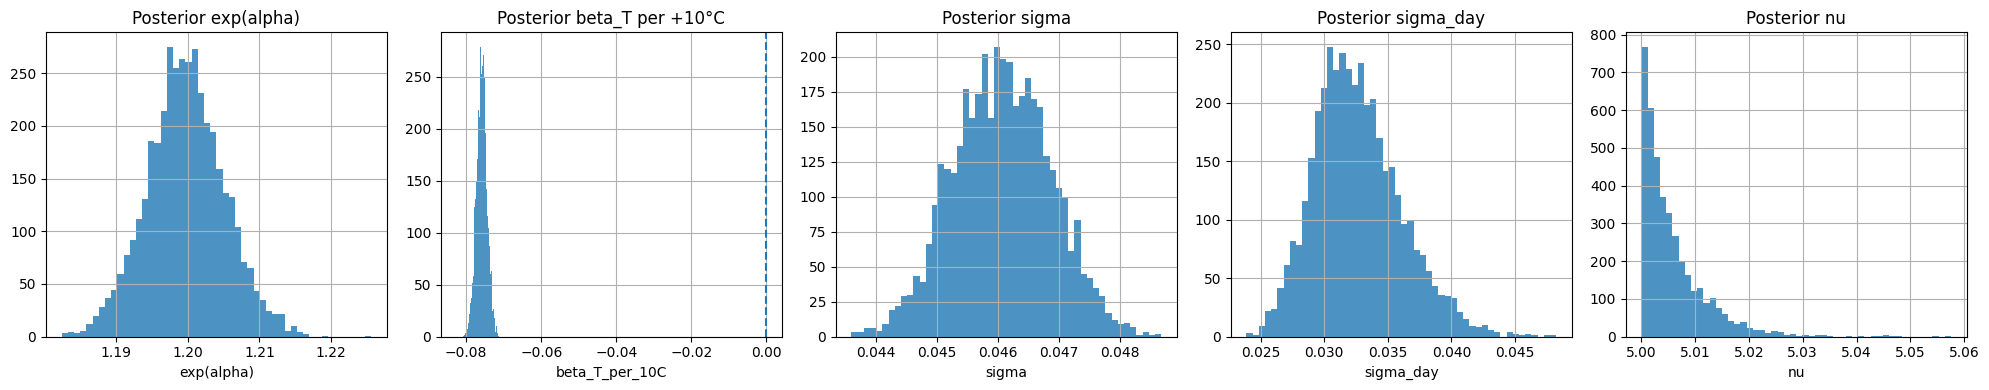

In [45]:
alpha = fit.stan_variable("alpha")
beta_T_per_10C = fit.stan_variable("beta_T_per_10C")
beta_T_norm = fit.stan_variable("beta_T")
sigma = fit.stan_variable("sigma")
sigma_day = fit.stan_variable("sigma_day")
nu = fit.stan_variable("nu")
mu = fit.stan_variable("mu")
delta_day = fit.stan_variable("delta_day")

print("nu [5%, 50%, 95%]:", np.percentile(nu, [5, 50, 95]))
print("sigma_day [5%, 50%, 95%]:", np.percentile(sigma_day, [5, 50, 95]))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

plots = [
    ("Posterior exp(alpha)", np.exp(alpha), "exp(alpha)", False),
    ("Posterior beta_T per +10°C", beta_T_per_10C, "beta_T_per_10C", True),
    ("Posterior sigma", sigma, "sigma", False),
    ("Posterior sigma_day", sigma_day, "sigma_day", False),
    ("Posterior nu", nu, "nu", False),
]

for ax, (title, samples, xlabel, zero) in zip(axes, plots):
    ax.hist(samples, bins=50, alpha=0.8)
    if zero:
        ax.axvline(0, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [46]:
p_beta_negative = np.mean(beta_T_per_10C < 0)

effect_10C_pct = 100 * (np.exp(beta_T_per_10C) - 1)
effect_1C_pct = 100 * (np.exp(beta_T_per_10C / 10) - 1)

print("P(beta_T_per_10C < 0):", round(p_beta_negative, 4))
print("Effect per +10°C [%], 5/50/95%:", np.round(np.percentile(effect_10C_pct, [5, 50, 95]), 3))
print("Effect per +1°C [%], 5/50/95%:", np.round(np.percentile(effect_1C_pct, [5, 50, 95]), 3))

P(beta_T_per_10C < 0): 1.0
Effect per +10°C [%], 5/50/95%: [-7.522 -7.306 -7.088]
Effect per +1°C [%], 5/50/95%: [-0.779 -0.756 -0.733]


The same temperature-effect quantity is evaluated for Model 2. This allows checking whether the estimated temperature loss remains negative after accounting for day-specific deviations.

### Posterior predictive check

The posterior predictive distribution of Model 2 was compared with the observed distribution of \(PR\). In this model, predictions include both the temperature effect and the estimated day-specific offsets. Therefore, the posterior predictive distribution checks whether the model can reproduce the overall spread of normalized PV performance after accounting for systematic day-to-day variation.

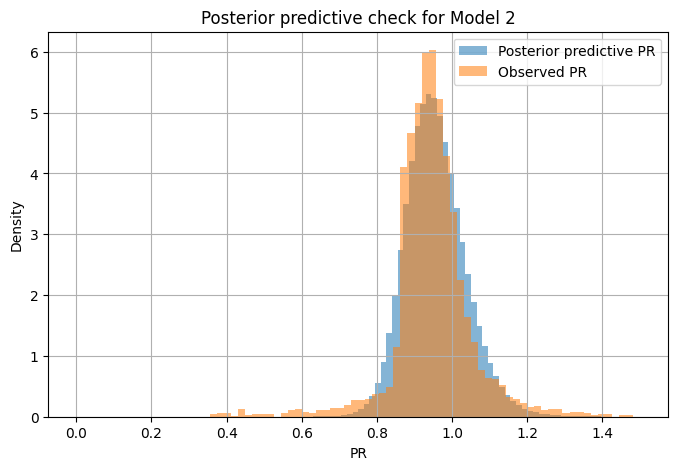

In [47]:
PR_pred = fit.stan_variable("PR_pred")
y_pred = fit.stan_variable("y_pred")

plt.figure(figsize=(8, 5))

plt.hist(
    PR_pred.flatten(),
    bins=100,
    range=(0, 1.5),
    density=True,
    alpha=0.55,
    label="Posterior predictive PR"
)

plt.hist(
    df["PR"],
    bins=80,
    range=(0, 1.5),
    density=True,
    alpha=0.55,
    label="Observed PR"
)

plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Posterior predictive check for Model 2")
plt.legend()
plt.grid(True)
plt.show()

### Daily offsets

The daily offsets show which days are systematically above or below the global temperature trend. Positive values indicate higher performance than expected from temperature alone. Negative values indicate lower performance than expected from temperature alone.

/tmp/ipykernel_106/4142912194.py:9: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  delta_day_hdi = az.hdi(delta_day, hdi_prob=0.9)
/tmp/ipykernel_106/4142912194.py:16: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  delta_day_pct_hdi = az.hdi(delta_day_pct, hdi_prob=0.9)


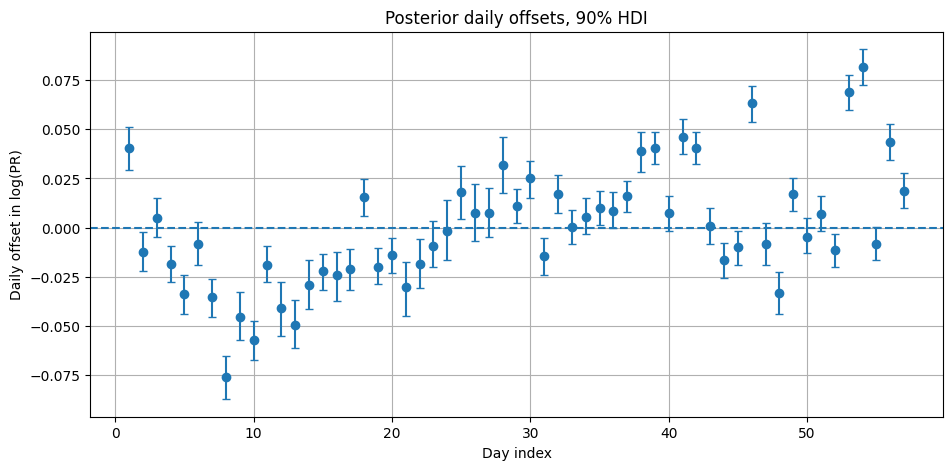

Most negative daily offsets:


,day_id,date,delta_mean,delta_5%,delta_95%,delta_pct_mean,delta_pct_5%,delta_pct_95%
7,8,2016-06-08,-0.0761,-0.0872,-0.0655,-7.3210,-8.3501,-6.3363
9,10,2016-06-10,-0.0571,-0.0673,-0.0472,-5.5436,-6.5125,-4.6132
12,13,2016-06-13,-0.0496,-0.0613,-0.0366,-4.8399,-5.9488,-3.5979
8,9,2016-06-09,-0.0454,-0.0571,-0.0328,-4.4321,-5.5531,-3.2252
11,12,2016-06-12,-0.0409,-0.0551,-0.0276,-4.0020,-5.3585,-2.7258


Most positive daily offsets:


,day_id,date,delta_mean,delta_5%,delta_95%,delta_pct_mean,delta_pct_5%,delta_pct_95%
53,54,2016-08-28,0.0816,0.0727,0.0907,8.4997,7.5386,9.4913
52,53,2016-08-27,0.0687,0.0598,0.0776,7.1115,6.1648,8.0636
45,46,2016-08-20,0.0634,0.0535,0.0720,6.5434,5.4929,7.4618
40,41,2016-08-15,0.0463,0.0376,0.0550,4.7413,3.8292,5.6517
55,56,2016-08-30,0.0433,0.0346,0.0527,4.4244,3.5186,5.4081


In [48]:
# Extract daily offsets from Model 2
delta_day = fit.stan_variable("delta_day")

# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Posterior summaries for daily offsets on log(PR) scale
delta_day_mean = delta_day.mean(axis=0)
delta_day_hdi = az.hdi(delta_day, hdi_prob=0.9)

day_numbers = np.arange(1, J + 1)

# Convert daily offsets from log(PR) scale to approximate percentage effect
delta_day_pct = 100 * (np.exp(delta_day) - 1)
delta_day_pct_mean = delta_day_pct.mean(axis=0)
delta_day_pct_hdi = az.hdi(delta_day_pct, hdi_prob=0.9)

# Plot daily offsets on log(PR) scale
plt.figure(figsize=(11, 5))
plt.errorbar(
    day_numbers,
    delta_day_mean,
    yerr=[
        delta_day_mean - delta_day_hdi[:, 0],
        delta_day_hdi[:, 1] - delta_day_mean,
    ],
    fmt="o",
    capsize=3,
)
plt.axhline(0, linestyle="--")
plt.xlabel("Day index")
plt.ylabel("Daily offset in log(PR)")
plt.title("Posterior daily offsets, 90% HDI")
plt.grid(True)
plt.show()

# Create summary table
daily_offsets = pd.DataFrame({
    "day_id": day_numbers,
    "delta_mean": delta_day_mean,
    "delta_5%": delta_day_hdi[:, 0],
    "delta_95%": delta_day_hdi[:, 1],
    "delta_pct_mean": delta_day_pct_mean,
    "delta_pct_5%": delta_day_pct_hdi[:, 0],
    "delta_pct_95%": delta_day_pct_hdi[:, 1],
})

# Add calendar dates for each day_id
daily_dates = (
    df.groupby("day_id")["timestamp"]
    .min()
    .dt.date
    .reset_index(name="date")
)

daily_offsets = daily_offsets.merge(daily_dates, on="day_id", how="left")

# Reorder columns
daily_offsets = daily_offsets[
    [
        "day_id",
        "date",
        "delta_mean",
        "delta_5%",
        "delta_95%",
        "delta_pct_mean",
        "delta_pct_5%",
        "delta_pct_95%",
    ]
]

print("Most negative daily offsets:")
display(daily_offsets.sort_values("delta_mean").head(5).round(4))

print("Most positive daily offsets:")
display(daily_offsets.sort_values("delta_mean", ascending=False).head(5).round(4))

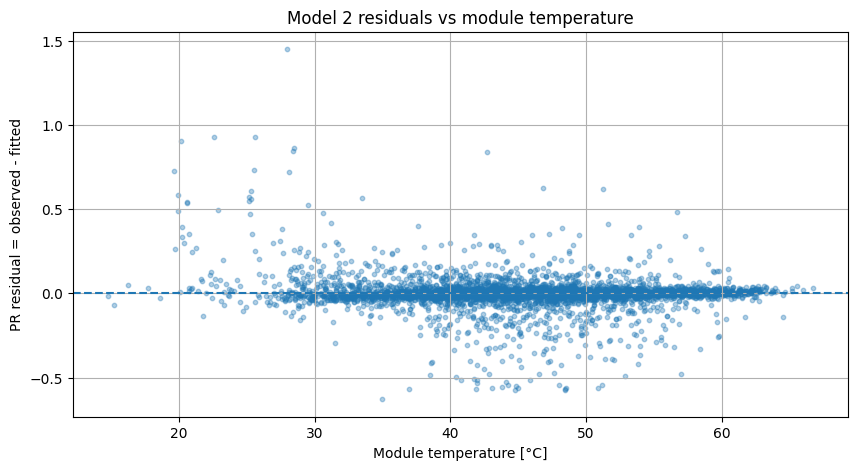

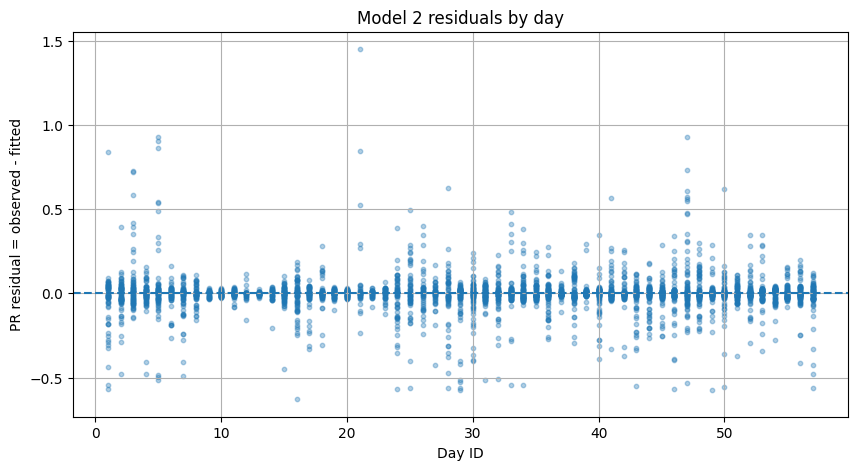

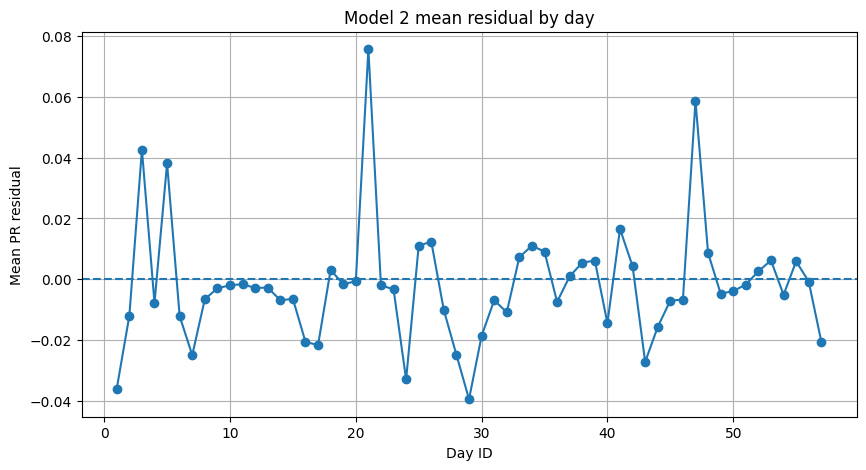

,day_id,date,mean_residual_PR,median_residual_PR,n
0,1,2016-06-01,-0.0359,-0.0078,70
1,2,2016-06-02,-0.0120,-0.0009,85
2,3,2016-06-03,0.0426,0.0089,79
3,4,2016-06-04,-0.0078,-0.0038,79
4,5,2016-06-05,0.0381,0.0050,80
5,6,2016-06-06,-0.0121,-0.0004,54
6,7,2016-06-07,-0.0249,0.0054,73
7,8,2016-06-08,-0.0065,-0.0032,60
8,9,2016-06-09,-0.0030,0.0030,34
9,10,2016-06-10,-0.0020,-0.0054,50


In [61]:

mu = fit.stan_variable("mu")

PR_fit_mean = np.exp(mu).mean(axis=0)


if len(PR_fit_mean) != len(df):
    raise ValueError("Length mismatch: df and fitted values do not have the same number of observations.")

# Prepare dataframe for residual checks
df_check = df.copy().reset_index(drop=True)
df_check["timestamp"] = pd.to_datetime(df_check["timestamp"])
df_check["PR_fit_mean"] = PR_fit_mean
df_check["residual_PR"] = df_check["PR"] - df_check["PR_fit_mean"]

# 1. Residuals vs module temperature
plt.figure(figsize=(10, 5))
plt.scatter(
    df_check["T_module_C"],
    df_check["residual_PR"],
    s=10,
    alpha=0.35
)
plt.axhline(0, linestyle="--")
plt.xlabel("Module temperature [°C]")
plt.ylabel("PR residual = observed - fitted")
plt.title("Model 2 residuals vs module temperature")
plt.grid(True)
plt.show()

# 2. Residuals by day, all observations
plt.figure(figsize=(10, 5))
plt.scatter(
    df_check["day_id"],
    df_check["residual_PR"],
    s=10,
    alpha=0.35
)
plt.axhline(0, linestyle="--")
plt.xlabel("Day ID")
plt.ylabel("PR residual = observed - fitted")
plt.title("Model 2 residuals by day")
plt.grid(True)
plt.show()

# 3. Mean residual by day
daily_residuals = (
    df_check
    .groupby("day_id")
    .agg(
        date=("timestamp", "min"),
        mean_residual_PR=("residual_PR", "mean"),
        median_residual_PR=("residual_PR", "median"),
        n=("residual_PR", "size")
    )
    .reset_index()
)

daily_residuals["date"] = pd.to_datetime(daily_residuals["date"]).dt.date

plt.figure(figsize=(10, 5))
plt.plot(
    daily_residuals["day_id"],
    daily_residuals["mean_residual_PR"],
    "o-"
)
plt.axhline(0, linestyle="--")
plt.xlabel("Day ID")
plt.ylabel("Mean PR residual")
plt.title("Model 2 mean residual by day")
plt.grid(True)
plt.show()

display(daily_residuals.round(4))

The comparison of mean daily residuals shows that the daily-offset model reduces systematic day-level errors. Model 2 residuals are more concentrated around zero than Model 1 residuals. This indicates that the added daily offsets capture meaningful day-to-day structure in the data.